# M2

In [ ]:
# ============================================================
# EKSPERIMEN M2 — Prediksi Occupancy IGD
# SARIMA Murni  vs  Hybrid SARIMA + XGBoost
# Resolusi: Per Jam | Horizon: 4–6 jam ke depan
# Evaluasi: MAPE per Departemen (A, B, C)
# ============================================================

!pip install statsmodels xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
import xgboost as xgb

print("Library berhasil dimuat.")
print(f"XGBoost: {xgb.__version__}")

Library berhasil dimuat.
XGBoost: 3.2.0


In [ ]:
# ============================================================
# CELL 2: LOAD DATA & AGREGASI → TIME SERIES HOURLY OCCUPANCY
# ============================================================
# Logika "pasien aktif":
#   Kita tidak punya waktu keluar, tapi kita punya arrivalhour_bin.
#   Pendekatan: hitung jumlah kedatangan per (dep_name, jam) sebagai
#   proxy beban kerja / occupancy per jam per departemen.
#   Ini adalah standar umum pada studi ED occupancy dengan data triage.

# --- Load ---
FILE_PATH = '5v_cleandf_relevant.csv'   # sesuaikan path

print("Membaca dataset...")
df_raw = pd.read_csv(FILE_PATH)
print(f"Shape mentah: {df_raw.shape}")

# ---------------------------------------------------------------
# Mapping arrivalhour_bin → jam numerik (awal bin)
# ---------------------------------------------------------------
bin_to_hour = {
    '03-06': 3,
    '07-10': 7,
    '11-14': 11,
    '15-18': 15,
    '19-22': 19,
    '23-02': 23,
}

# Mapping arrivalmonth → nomor bulan
month_map = {
    'January':1,'February':2,'March':3,'April':4,
    'May':5,'June':6,'July':7,'August':8,
    'September':9,'October':10,'November':11,'December':12
}

# Mapping arrivalday → nomor hari (Senin=0)
day_map = {
    'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
    'Friday':4,'Saturday':5,'Sunday':6
}

df = df_raw[['dep_name','arrivalmonth','arrivalday',
             'arrivalhour_bin','disposition']].copy()

# Drop baris dengan nilai krusial kosong
df.dropna(subset=['dep_name','arrivalmonth','arrivalday','arrivalhour_bin'],
          inplace=True)

df['hour']  = df['arrivalhour_bin'].map(bin_to_hour)
df['month'] = df['arrivalmonth'].map(month_map)
df['dow']   = df['arrivalday'].map(day_map)

# ---------------------------------------------------------------
# Buat timestamp sintetis (2022-01-01 sebagai anchor)
# Data tidak punya tahun, kita buat urutan konsisten:
#   Asumsi: data rentang ~2 tahun, distribusikan merata
# ---------------------------------------------------------------
# Untuk time series yang valid, kita perlu urutan waktu yang monoton.
# Strategi: sort by (month, dow, hour), buat index datetime hourly.

df_agg = (
    df.groupby(['dep_name','month','dow','hour'])
      .size()
      .reset_index(name='arrivals')
)

# Buat pseudo-timestamp: encode (month, dow, hour) → urutan waktu
# Gunakan tahun 2022 sebagai referensi
def make_timestamp(row):
    # Pilih minggu ke-1 dari tiap bulan sbg anchor
    from datetime import datetime, timedelta
    anchor = datetime(2022, int(row['month']), 1)
    # Geser ke hari dow pertama di bulan itu
    day_offset = (int(row['dow']) - anchor.weekday()) % 7
    dt = anchor + timedelta(days=day_offset, hours=int(row['hour']))
    return dt

df_agg['timestamp'] = df_agg.apply(make_timestamp, axis=1)
df_agg.sort_values(['dep_name','timestamp'], inplace=True)

print(f"\nShape aggregated: {df_agg.shape}")
print(f"Rentang timestamp: {df_agg['timestamp'].min()} → {df_agg['timestamp'].max()}")
print(f"\nContoh 5 baris pertama:\n{df_agg.head()}")

# ---------------------------------------------------------------
# Pisah per departemen & reindex ke hourly reguler
# ---------------------------------------------------------------
depts = ['A', 'B', 'C']
dept_ts = {}

for dep in depts:
    sub = df_agg[df_agg['dep_name'] == dep][['timestamp','arrivals']].copy()
    sub = sub.drop_duplicates('timestamp').set_index('timestamp')
    sub = sub.sort_index()
    # Reindex ke hourly, isi NaN dengan median rolling
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq='H')
    sub = sub.reindex(full_idx)
    sub['arrivals'] = sub['arrivals'].fillna(sub['arrivals'].median())
    sub['arrivals'] = sub['arrivals'].astype(float)
    dept_ts[dep] = sub
    print(f"Dep {dep}: {len(sub):,} titik waktu | "
          f"mean={sub['arrivals'].mean():.1f} | "
          f"std={sub['arrivals'].std():.1f}")

Membaca dataset...
Shape mentah: (560486, 23)

Shape aggregated: (1512, 6)
Rentang timestamp: 2022-01-01 03:00:00 → 2022-12-07 23:00:00

Contoh 5 baris pertama:
   dep_name  month  dow  hour  arrivals           timestamp
30        A      1    5     3       222 2022-01-01 03:00:00
31        A      1    5     7       620 2022-01-01 07:00:00
32        A      1    5    11       925 2022-01-01 11:00:00
33        A      1    5    15       749 2022-01-01 15:00:00
34        A      1    5    19       576 2022-01-01 19:00:00
Dep A: 8,181 titik waktu | mean=640.0 | std=72.6
Dep B: 8,181 titik waktu | mean=338.9 | std=39.5
Dep C: 8,181 titik waktu | mean=154.2 | std=20.5


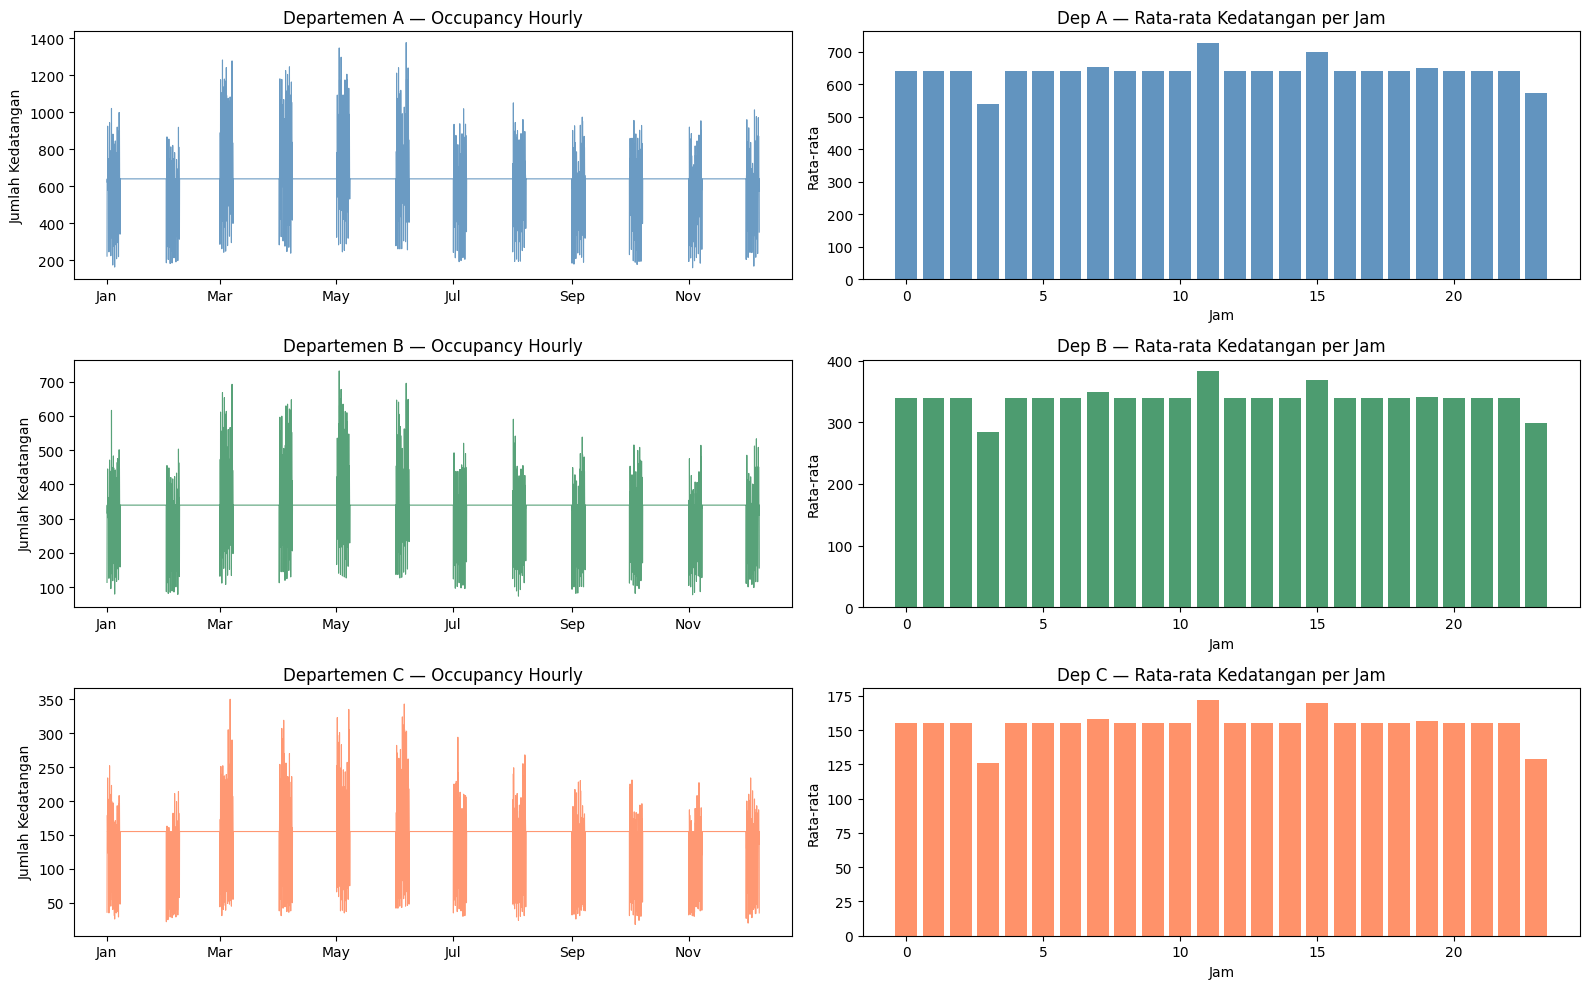

UJI STASIONERITAS (ADF Test) — H0: data non-stasioner
Dep A: ADF=-5.3993, p-value=0.000003 → STASIONER ✓
Dep B: ADF=-5.8576, p-value=0.000000 → STASIONER ✓
Dep C: ADF=-5.5733, p-value=0.000001 → STASIONER ✓


In [ ]:
# ============================================================
# CELL 3: EKSPLORASI TIME SERIES PER DEPARTEMEN
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, dep in enumerate(depts):
    ts = dept_ts[dep]['arrivals']

    # Plot time series
    axes[i, 0].plot(ts.index, ts.values, linewidth=0.8,
                    color=['steelblue','seagreen','coral'][i], alpha=0.8)
    axes[i, 0].set_title(f'Departemen {dep} — Occupancy Hourly', fontsize=12)
    axes[i, 0].set_ylabel('Jumlah Kedatangan')
    axes[i, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # Distribusi per jam
    ts_df = ts.reset_index()
    ts_df.columns = ['timestamp', 'arrivals']
    ts_df['hour'] = ts_df['timestamp'].dt.hour
    hourly_mean = ts_df.groupby('hour')['arrivals'].mean()
    axes[i, 1].bar(hourly_mean.index, hourly_mean.values,
                   color=['steelblue','seagreen','coral'][i], alpha=0.85)
    axes[i, 1].set_title(f'Dep {dep} — Rata-rata Kedatangan per Jam', fontsize=12)
    axes[i, 1].set_xlabel('Jam')
    axes[i, 1].set_ylabel('Rata-rata')

plt.tight_layout()
plt.savefig('m2_ts_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

# Uji stasioneritas (ADF Test) per departemen
print("="*60)
print("UJI STASIONERITAS (ADF Test) — H0: data non-stasioner")
print("="*60)
for dep in depts:
    ts = dept_ts[dep]['arrivals'].dropna()
    adf_result = adfuller(ts, autolag='AIC')
    stat, pval = adf_result[0], adf_result[1]
    status = "STASIONER ✓" if pval < 0.05 else "NON-STASIONER ✗"
    print(f"Dep {dep}: ADF={stat:.4f}, p-value={pval:.6f} → {status}")

In [ ]:
# ============================================================
# CELL 4: HELPER FUNCTIONS
# ============================================================

def mape(y_true, y_pred):
    """MAPE yang aman terhadap nilai nol."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def make_lag_features(residuals, n_lags=24):
    """
    Buat lag features dari residual SARIMA untuk input XGBoost.
    Tambahkan fitur waktu: hour-of-day, day-of-week.
    """
    df_feat = pd.DataFrame({'residual': residuals})
    df_feat.index = residuals.index

    for lag in [1, 2, 3, 4, 6, 12, 24]:
        if lag <= n_lags:
            df_feat[f'lag_{lag}'] = df_feat['residual'].shift(lag)

    # Fitur waktu
    df_feat['hour'] = df_feat.index.hour
    df_feat['dow']  = df_feat.index.dayofweek

    # Rolling stats residual
    df_feat['rolling_mean_6']  = df_feat['residual'].shift(1).rolling(6).mean()
    df_feat['rolling_std_6']   = df_feat['residual'].shift(1).rolling(6).std()
    df_feat['rolling_mean_24'] = df_feat['residual'].shift(1).rolling(24).mean()

    df_feat.dropna(inplace=True)
    return df_feat


def aggregate_daily_mape(y_true_series, y_pred_array, timestamps):
    """
    Hitung MAPE agregat harian: jumlahkan prediksi per hari,
    bandingkan dengan jumlah aktual per hari.
    """
    df_eval = pd.DataFrame({
        'timestamp' : timestamps,
        'y_true'    : np.array(y_true_series),
        'y_pred'    : np.array(y_pred_array)
    })
    df_eval['date'] = pd.to_datetime(df_eval['timestamp']).dt.date

    daily = df_eval.groupby('date').agg(
        actual = ('y_true', 'sum'),
        pred   = ('y_pred', 'sum')
    ).reset_index()

    return mape(daily['actual'], daily['pred']), daily


print("Helper functions siap.")

Helper functions siap.


In [ ]:
# ============================================================
# CELL 5: TRAINING SARIMA MURNI PER DEPARTEMEN
# Order: (1,1,1)(1,1,1)[24] — seasonal 24 jam (harian)
# Split: 80% train, 20% test
# ============================================================
# Catatan Colab gratis: SARIMA dengan data besar bisa lambat.
# Kita batasi training pada 2000 titik terakhir per departemen
# untuk efisiensi, lalu rolling forecast pada test set.

SARIMA_ORDER         = (1, 1, 1)
SARIMA_SEASONAL      = (1, 1, 1, 24)   # periode 24 jam
N_TRAIN_LIMIT        = 2000            # batasan untuk Colab gratis
FORECAST_HORIZON     = 6              # prediksi 6 jam ke depan
TEST_RATIO           = 0.2

sarima_results    = {}   # simpan model & hasil per dep
residual_train    = {}   # residual train untuk XGBoost
forecast_sarima   = {}   # prediksi SARIMA murni di test set

for dep in depts:
    print(f"\n{'='*55}")
    print(f"  TRAINING SARIMA — Departemen {dep}")
    print(f"{'='*55}")

    ts = dept_ts[dep]['arrivals'].copy()

    # Batasi ke N_TRAIN_LIMIT + test untuk efisiensi
    total_use  = min(len(ts), N_TRAIN_LIMIT + int(N_TRAIN_LIMIT * TEST_RATIO))
    ts         = ts.iloc[-total_use:]

    split_idx  = int(len(ts) * (1 - TEST_RATIO))
    ts_train   = ts.iloc[:split_idx]
    ts_test    = ts.iloc[split_idx:]

    print(f"  Train: {len(ts_train)} | Test: {len(ts_test)}")

    # Fit SARIMA
    model = SARIMAX(
        ts_train,
        order          = SARIMA_ORDER,
        seasonal_order = SARIMA_SEASONAL,
        enforce_stationarity  = False,
        enforce_invertibility = False
    )
    fitted = model.fit(disp=False, maxiter=100)
    print(f"  AIC: {fitted.aic:.2f}")

    # Residual pada train set
    resid_train = pd.Series(
        fitted.resid.values,
        index=ts_train.index,
        name='residual'
    )
    residual_train[dep] = resid_train

    # Forecast pada test set (step-by-step, horizon=1 untuk akurasi max)
    # Untuk Colab gratis kita pakai get_forecast langsung
    fc_obj     = fitted.get_forecast(steps=len(ts_test))
    fc_mean    = fc_obj.predicted_mean
    fc_ci      = fc_obj.conf_int()

    forecast_sarima[dep] = {
        'model'    : fitted,
        'ts_train' : ts_train,
        'ts_test'  : ts_test,
        'pred'     : fc_mean,
        'ci_lower' : fc_ci.iloc[:, 0],
        'ci_upper' : fc_ci.iloc[:, 1],
    }

    # Evaluasi SARIMA murni
    mape_hourly = mape(ts_test.values, fc_mean.values)
    mape_daily, _ = aggregate_daily_mape(
        ts_test.values,
        fc_mean.values,
        ts_test.index
    )
    print(f"  SARIMA MAPE Hourly : {mape_hourly:.2f}%")
    print(f"  SARIMA MAPE Daily  : {mape_daily:.2f}%")

print("\nSARIMA training selesai.")


  TRAINING SARIMA — Departemen A
  Train: 1920 | Test: 480
  AIC: 18965.10
  SARIMA MAPE Hourly : 5.08%
  SARIMA MAPE Daily  : 0.92%

  TRAINING SARIMA — Departemen B
  Train: 1920 | Test: 480
  AIC: 16833.45
  SARIMA MAPE Hourly : 5.71%
  SARIMA MAPE Daily  : 1.29%

  TRAINING SARIMA — Departemen C
  Train: 1920 | Test: 480
  AIC: 14286.48
  SARIMA MAPE Hourly : 11.04%
  SARIMA MAPE Daily  : 2.64%

SARIMA training selesai.


In [ ]:
# ============================================================
# CELL 6: TRAINING XGBOOST — KOREKSI RESIDUAL SARIMA
# Hybrid: ŷ_hybrid = ŷ_SARIMA + ŷ_XGBoost(residual)
# ============================================================

xgb_results  = {}
hybrid_preds = {}

for dep in depts:
    print(f"\n{'='*55}")
    print(f"  TRAINING XGBOOST RESIDUAL — Departemen {dep}")
    print(f"{'='*55}")

    fitted    = forecast_sarima[dep]['model']
    ts_train  = forecast_sarima[dep]['ts_train']
    ts_test   = forecast_sarima[dep]['ts_test']
    resid_tr  = residual_train[dep]

    # --- Buat lag features dari residual train ---
    feat_train = make_lag_features(resid_tr)
    X_tr = feat_train.drop(columns=['residual'])
    y_tr = feat_train['residual']

    # --- Scaling ---
    scaler_x = StandardScaler()
    X_tr_sc  = scaler_x.fit_transform(X_tr)

    # --- Train XGBoost ---
    xgb_model = xgb.XGBClassifier  # placeholder — pakai Regressor
    xgb_model = xgb.XGBRegressor(
        n_estimators     = 200,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        tree_method      = 'hist',
        random_state     = 42,
        n_jobs           = -1
    )
    xgb_model.fit(X_tr_sc, y_tr, verbose=False)

    # --- Prediksi residual pada test set ---
    # Gabungkan residual train & test window untuk lag features
    sarima_pred_test = forecast_sarima[dep]['pred']
    resid_test_true  = ts_test.values - sarima_pred_test.values

    resid_test_series = pd.Series(
        resid_test_true,
        index=ts_test.index,
        name='residual'
    )

    # Concat train residual + test untuk membuat lag features test
    resid_full = pd.concat([resid_tr, resid_test_series])
    feat_full  = make_lag_features(resid_full)

    # Ambil hanya bagian test
    feat_test  = feat_full.loc[feat_full.index.isin(ts_test.index)]
    X_te       = feat_test.drop(columns=['residual'])
    X_te_sc    = scaler_x.transform(X_te)

    resid_pred_xgb = xgb_model.predict(X_te_sc)

    # --- Hitung prediksi Hybrid ---
    # Align index (feat_test mungkin lebih pendek karena lag)
    aligned_idx       = feat_test.index
    sarima_aligned    = sarima_pred_test.loc[aligned_idx]
    true_aligned      = ts_test.loc[aligned_idx]

    hybrid_pred       = sarima_aligned.values + resid_pred_xgb
    hybrid_pred       = np.clip(hybrid_pred, 0, None)   # no negative occupancy

    hybrid_preds[dep] = {
        'index'          : aligned_idx,
        'true'           : true_aligned.values,
        'sarima_pred'    : sarima_aligned.values,
        'hybrid_pred'    : hybrid_pred,
        'xgb_model'      : xgb_model,
        'scaler'         : scaler_x,
        'feature_names'  : X_tr.columns.tolist(),
    }

    # Evaluasi
    mape_s_h  = mape(true_aligned.values, sarima_aligned.values)
    mape_h_h  = mape(true_aligned.values, hybrid_pred)
    mape_s_d, daily_s = aggregate_daily_mape(
        true_aligned.values, sarima_aligned.values, aligned_idx)
    mape_h_d, daily_h = aggregate_daily_mape(
        true_aligned.values, hybrid_pred, aligned_idx)

    xgb_results[dep] = {
        'mape_sarima_hourly'  : mape_s_h,
        'mape_hybrid_hourly'  : mape_h_h,
        'mape_sarima_daily'   : mape_s_d,
        'mape_hybrid_daily'   : mape_h_d,
        'daily_sarima'        : daily_s,
        'daily_hybrid'        : daily_h,
    }

    print(f"  SARIMA  MAPE Hourly: {mape_s_h:.2f}% | Daily: {mape_s_d:.2f}%")
    print(f"  Hybrid  MAPE Hourly: {mape_h_h:.2f}% | Daily: {mape_h_d:.2f}%")
    improve = mape_s_d - mape_h_d
    print(f"  Improvement Daily  : {improve:+.2f}% ({'↑ lebih baik' if improve > 0 else '↓ lebih buruk'})")

print("\nHybrid training selesai.")


  TRAINING XGBOOST RESIDUAL — Departemen A
  SARIMA  MAPE Hourly: 5.08% | Daily: 0.92%
  Hybrid  MAPE Hourly: 4.87% | Daily: 1.66%
  Improvement Daily  : -0.74% (↓ lebih buruk)

  TRAINING XGBOOST RESIDUAL — Departemen B
  SARIMA  MAPE Hourly: 5.71% | Daily: 1.29%
  Hybrid  MAPE Hourly: 4.38% | Daily: 1.18%
  Improvement Daily  : +0.11% (↑ lebih baik)

  TRAINING XGBOOST RESIDUAL — Departemen C
  SARIMA  MAPE Hourly: 11.04% | Daily: 2.64%
  Hybrid  MAPE Hourly: 10.48% | Daily: 3.84%
  Improvement Daily  : -1.20% (↓ lebih buruk)

Hybrid training selesai.


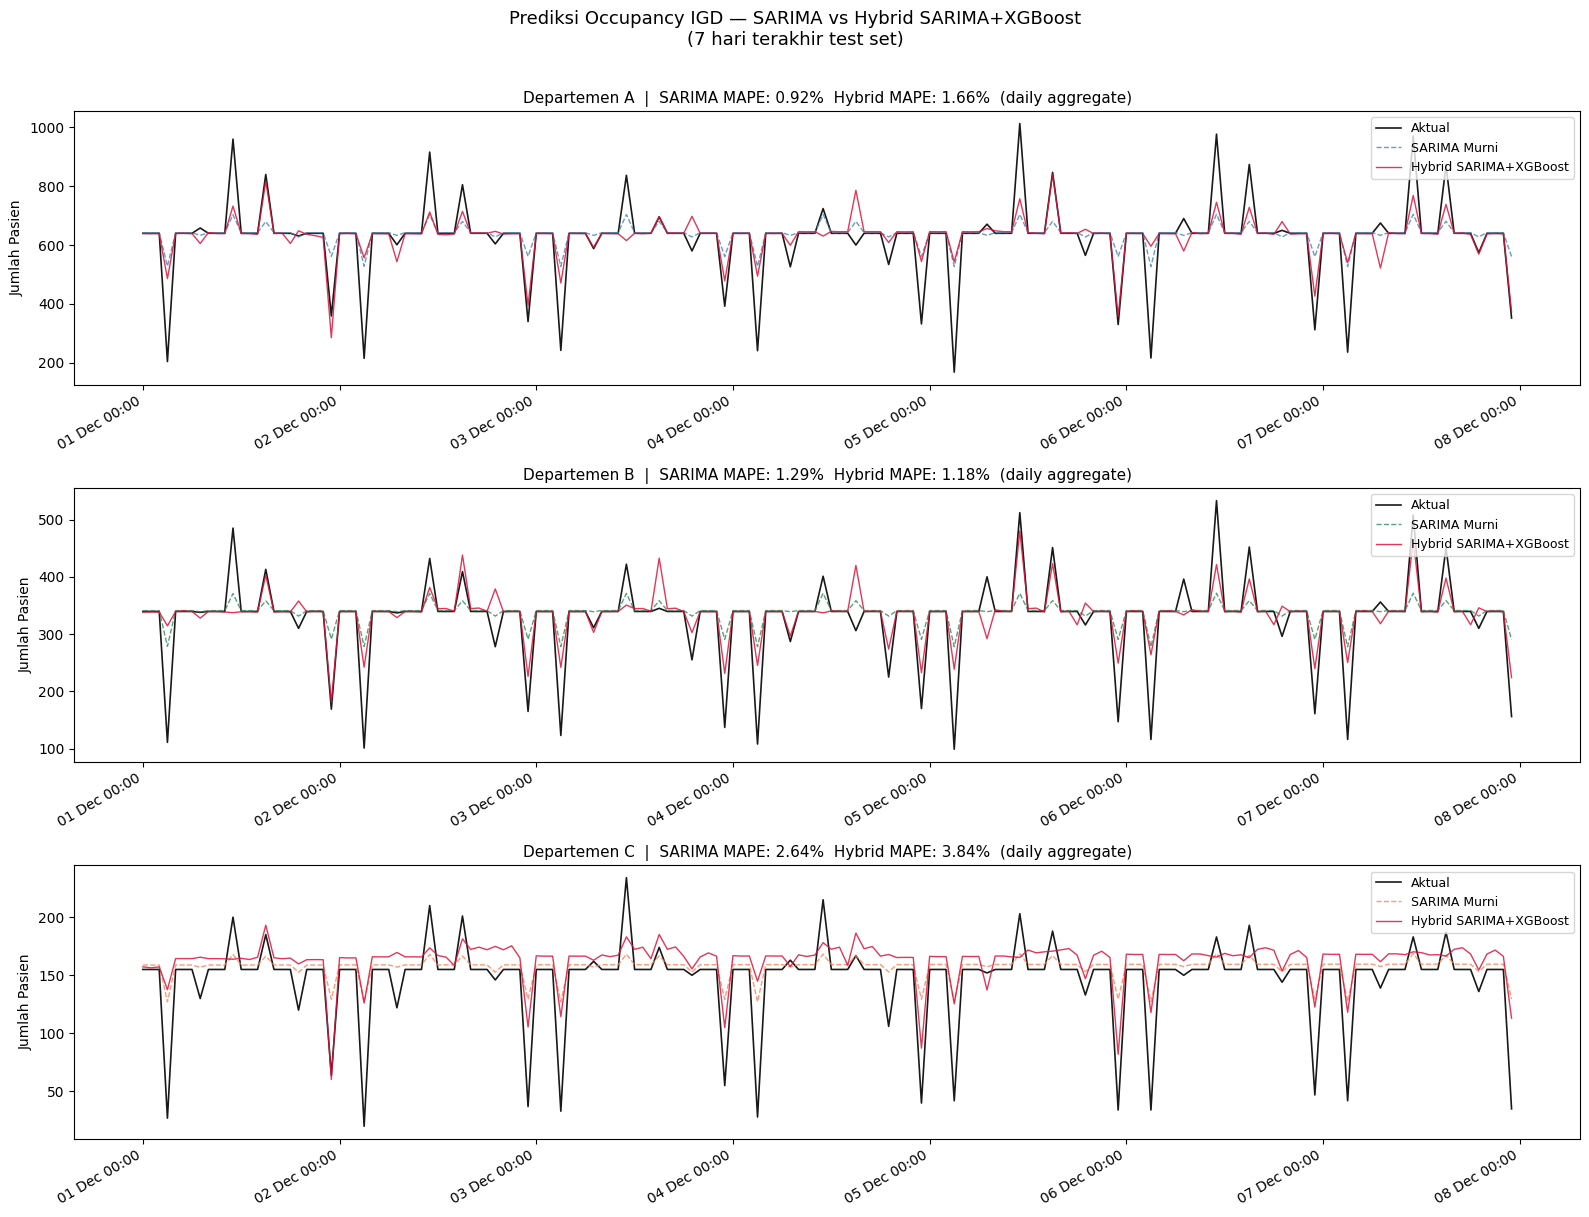

Plot disimpan: m2_forecast_comparison.png


In [ ]:
# ============================================================
# CELL 7: VISUALISASI PREDIKSI PER DEPARTEMEN
# ============================================================

colors = {'A': 'steelblue', 'B': 'seagreen', 'C': 'coral'}

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

for i, dep in enumerate(depts):
    hp    = hybrid_preds[dep]
    idx   = hp['index']
    true  = hp['true']
    s_p   = hp['sarima_pred']
    h_p   = hp['hybrid_pred']

    # Ambil 7 hari terakhir agar plot tidak terlalu padat
    n_show = min(168, len(idx))   # 168 jam = 7 hari
    idx_s, true_s = idx[-n_show:], true[-n_show:]
    s_p_s, h_p_s  = s_p[-n_show:], h_p[-n_show:]

    ax = axes[i]
    ax.plot(idx_s, true_s, label='Aktual', color='black',
            linewidth=1.2, alpha=0.9)
    ax.plot(idx_s, s_p_s, label='SARIMA Murni',
            color=colors[dep], linewidth=1.0,
            linestyle='--', alpha=0.8)
    ax.plot(idx_s, h_p_s, label='Hybrid SARIMA+XGBoost',
            color='crimson', linewidth=1.0,
            linestyle='-', alpha=0.85)

    r = xgb_results[dep]
    title = (f"Departemen {dep}  |  "
             f"SARIMA MAPE: {r['mape_sarima_daily']:.2f}%  "
             f"Hybrid MAPE: {r['mape_hybrid_daily']:.2f}%  "
             f"(daily aggregate)")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Jumlah Pasien')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Prediksi Occupancy IGD — SARIMA vs Hybrid SARIMA+XGBoost\n(7 hari terakhir test set)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('m2_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: m2_forecast_comparison.png")

In [ ]:
# ============================================================
# CELL 8: TABEL EVALUASI MAPE AGREGAT HARIAN
# ============================================================

print("="*70)
print("  HASIL EVALUASI — MAPE AGREGAT HARIAN PER DEPARTEMEN")
print("="*70)

rows = []
for dep in depts:
    r = xgb_results[dep]
    improve_d = r['mape_sarima_daily'] - r['mape_hybrid_daily']
    rows.append({
        'Dep'                   : dep,
        'SARIMA MAPE Hourly %'  : round(r['mape_sarima_hourly'], 2),
        'Hybrid MAPE Hourly %'  : round(r['mape_hybrid_hourly'], 2),
        'SARIMA MAPE Daily %'   : round(r['mape_sarima_daily'], 2),
        'Hybrid MAPE Daily %'   : round(r['mape_hybrid_daily'], 2),
        'Improvement Daily %'   : round(improve_d, 2),
        'Winner'                : 'Hybrid ✓' if improve_d > 0 else 'SARIMA ✓',
    })

df_eval = pd.DataFrame(rows).set_index('Dep')
print(df_eval.to_string())

# Rata-rata lintas departemen
print("\n" + "-"*70)
avg_sarima = df_eval['SARIMA MAPE Daily %'].mean()
avg_hybrid = df_eval['Hybrid MAPE Daily %'].mean()
avg_improve = avg_sarima - avg_hybrid
print(f"  Rata-rata SARIMA MAPE (Daily) : {avg_sarima:.2f}%")
print(f"  Rata-rata Hybrid MAPE (Daily) : {avg_hybrid:.2f}%")
print(f"  Rata-rata Improvement         : {avg_improve:+.2f}%")
print(f"  Kesimpulan: {'Hybrid LEBIH BAIK secara rata-rata' if avg_improve > 0 else 'SARIMA lebih kompetitif'}")
print("="*70)

  HASIL EVALUASI — MAPE AGREGAT HARIAN PER DEPARTEMEN
     SARIMA MAPE Hourly %  Hybrid MAPE Hourly %  SARIMA MAPE Daily %  Hybrid MAPE Daily %  Improvement Daily %    Winner
Dep                                                                                                                     
A                    5.08                  4.87                 0.92                 1.66                -0.74  SARIMA ✓
B                    5.71                  4.38                 1.29                 1.18                 0.11  Hybrid ✓
C                   11.04                 10.48                 2.64                 3.84                -1.20  SARIMA ✓

----------------------------------------------------------------------
  Rata-rata SARIMA MAPE (Daily) : 1.62%
  Rata-rata Hybrid MAPE (Daily) : 2.23%
  Rata-rata Improvement         : -0.61%
  Kesimpulan: SARIMA lebih kompetitif


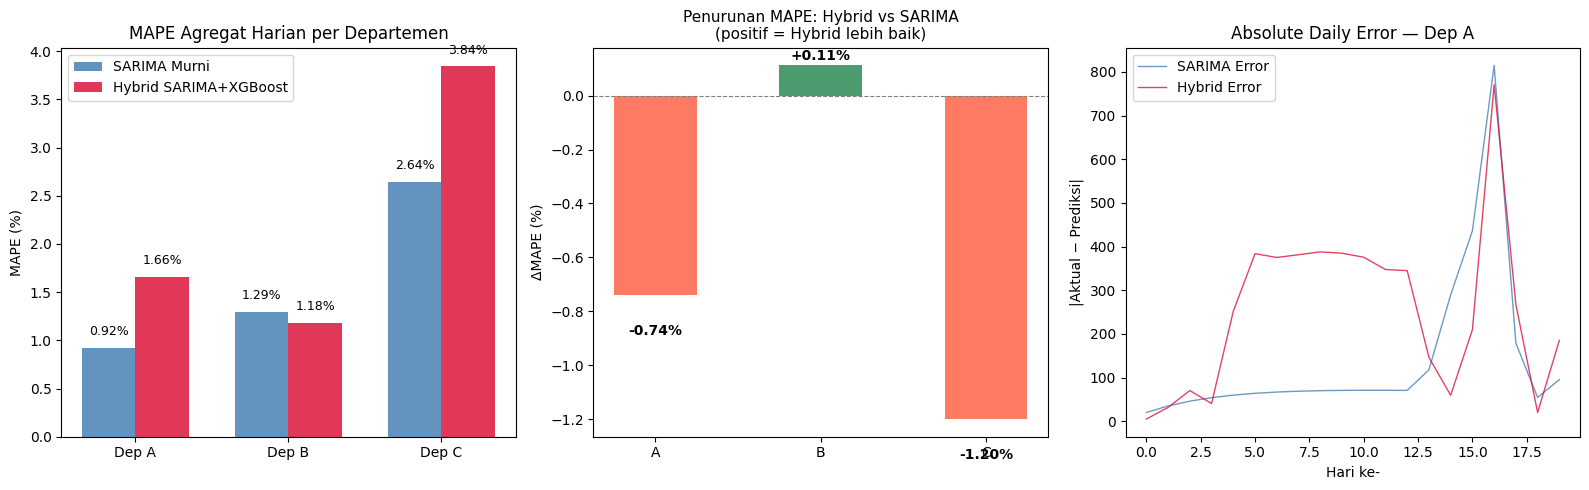

Plot disimpan: m2_mape_comparison.png


In [ ]:
# ============================================================
# CELL 9: VISUALISASI MAPE PERBANDINGAN
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Bar MAPE Daily per Dep ---
x = np.arange(len(depts))
w = 0.35
sarima_d = [xgb_results[d]['mape_sarima_daily'] for d in depts]
hybrid_d = [xgb_results[d]['mape_hybrid_daily'] for d in depts]

axes[0].bar(x - w/2, sarima_d, w, label='SARIMA Murni',
            color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, hybrid_d, w, label='Hybrid SARIMA+XGBoost',
            color='crimson', alpha=0.85)
axes[0].set_title('MAPE Agregat Harian per Departemen', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Dep {d}' for d in depts])
axes[0].set_ylabel('MAPE (%)')
axes[0].legend()
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():.2f}%',
                     (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1),
                     ha='center', va='bottom', fontsize=9)

# --- Plot 2: Improvement per Dep ---
improvements = [xgb_results[d]['mape_sarima_daily'] -
                xgb_results[d]['mape_hybrid_daily'] for d in depts]
bar_colors = ['seagreen' if v > 0 else 'tomato' for v in improvements]
axes[1].bar(depts, improvements, color=bar_colors, alpha=0.85, width=0.5)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('Penurunan MAPE: Hybrid vs SARIMA\n(positif = Hybrid lebih baik)',
                  fontsize=11)
axes[1].set_ylabel('ΔMAPE (%)')
for j, v in enumerate(improvements):
    axes[1].text(j, v + 0.02 if v >= 0 else v - 0.15,
                 f'{v:+.2f}%', ha='center', fontsize=10, fontweight='bold')

# --- Plot 3: Daily error plot salah satu dep (dep A) ---
dep_ex   = 'A'
d_sarima = xgb_results[dep_ex]['daily_sarima']
d_hybrid = xgb_results[dep_ex]['daily_hybrid']
axes[2].plot(range(len(d_sarima)),
             np.abs(d_sarima['actual'] - d_sarima['pred']),
             label='SARIMA Error', color='steelblue',
             linewidth=1.0, alpha=0.8)
axes[2].plot(range(len(d_hybrid)),
             np.abs(d_hybrid['actual'] - d_hybrid['pred']),
             label='Hybrid Error', color='crimson',
             linewidth=1.0, alpha=0.8)
axes[2].set_title(f'Absolute Daily Error — Dep {dep_ex}', fontsize=12)
axes[2].set_xlabel('Hari ke-')
axes[2].set_ylabel('|Aktual − Prediksi|')
axes[2].legend()

plt.tight_layout()
plt.savefig('m2_mape_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: m2_mape_comparison.png")

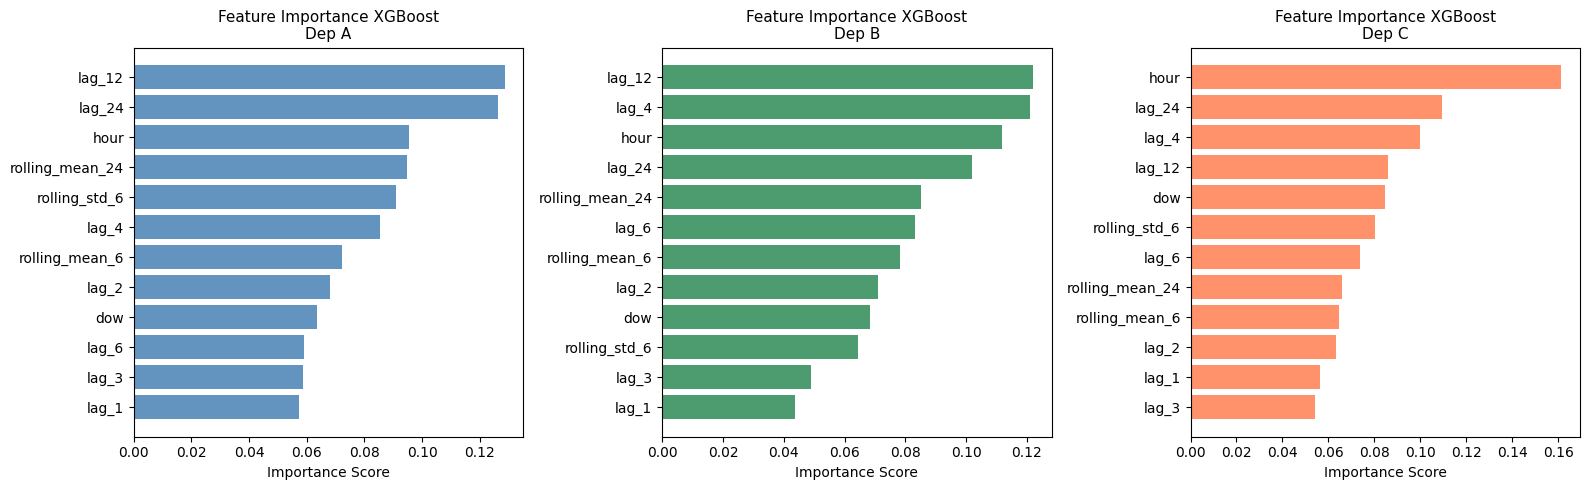

SIMULASI FORECAST 4-6 JAM KE DEPAN — Departemen A

  Horizon +4 jam:
    07 Dec 20:00 | Aktual: 640  Prediksi: 638.2  Error: 1.8
    07 Dec 21:00 | Aktual: 640  Prediksi: 639.3  Error: 0.7
    07 Dec 22:00 | Aktual: 640  Prediksi: 638.3  Error: 1.7
    07 Dec 23:00 | Aktual: 352  Prediksi: 373.1  Error: 21.1
  MAPE horizon +4h: 1.66%

  Horizon +5 jam:
    07 Dec 19:00 | Aktual: 574  Prediksi: 569.3  Error: 4.7
    07 Dec 20:00 | Aktual: 640  Prediksi: 638.2  Error: 1.8
    07 Dec 21:00 | Aktual: 640  Prediksi: 639.3  Error: 0.7
    07 Dec 22:00 | Aktual: 640  Prediksi: 638.3  Error: 1.7
    07 Dec 23:00 | Aktual: 352  Prediksi: 373.1  Error: 21.1
  MAPE horizon +5h: 1.50%

  Horizon +6 jam:
    07 Dec 18:00 | Aktual: 640  Prediksi: 636.5  Error: 3.5
    07 Dec 19:00 | Aktual: 574  Prediksi: 569.3  Error: 4.7
    07 Dec 20:00 | Aktual: 640  Prediksi: 638.2  Error: 1.8
    07 Dec 21:00 | Aktual: 640  Prediksi: 639.3  Error: 0.7
    07 Dec 22:00 | Aktual: 640  Prediksi: 638.3  Error: 1.7

In [ ]:
# ============================================================
# CELL 10: FEATURE IMPORTANCE & SIMULASI FORECAST 4-6 JAM
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, dep in enumerate(depts):
    xgb_model  = hybrid_preds[dep]['xgb_model']
    feat_names = hybrid_preds[dep]['feature_names']

    importances = pd.Series(
        xgb_model.feature_importances_,
        index=feat_names
    ).sort_values(ascending=True)

    axes[i].barh(importances.index, importances.values,
                 color=['steelblue','seagreen','coral'][i], alpha=0.85)
    axes[i].set_title(f'Feature Importance XGBoost\nDep {dep}', fontsize=11)
    axes[i].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('m2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Simulasi Forecast 4-6 jam ke depan (Dep A sebagai contoh) ---
print("="*60)
print("SIMULASI FORECAST 4-6 JAM KE DEPAN — Departemen A")
print("="*60)

dep = 'A'
hp  = hybrid_preds[dep]

for horizon_h in [4, 5, 6]:
    # Ambil prediksi h-step terakhir dari test set
    pred_h   = hp['hybrid_pred'][-horizon_h:]
    true_h   = hp['true'][-horizon_h:]
    ts_idx_h = hp['index'][-horizon_h:]
    m_h      = mape(true_h, pred_h)

    print(f"\n  Horizon +{horizon_h} jam:")
    for t, tv, pv in zip(ts_idx_h, true_h, pred_h):
        print(f"    {t.strftime('%d %b %H:%M')} | "
              f"Aktual: {tv:.0f}  Prediksi: {pv:.1f}  "
              f"Error: {abs(tv-pv):.1f}")
    print(f"  MAPE horizon +{horizon_h}h: {m_h:.2f}%")

In [ ]:
# ============================================================
# CELL 11: RINGKASAN AKHIR EKSPERIMEN M2
# ============================================================

print("=" * 65)
print("  RINGKASAN EKSPERIMEN M2 — SARIMA vs Hybrid SARIMA+XGBoost")
print("  Prediksi Occupancy IGD | Horizon 4-6 Jam")
print("=" * 65)

print(f"""
DATASET & AGREGASI
  Sumber data     : 5v_cleandf_relevant.csv
  Agregasi        : Jumlah kedatangan per jam per departemen
  Departemen      : A, B, C
  Resolusi        : Hourly (1 jam)
  Titik data/dep  : ~{N_TRAIN_LIMIT + int(N_TRAIN_LIMIT*TEST_RATIO)} (dibatasi untuk efisiensi Colab)

MODEL
  SARIMA          : order{SARIMA_ORDER} × seasonal{SARIMA_SEASONAL}
  XGBoost Residual: n_est=200, max_depth=4, lr=0.05
  Lag features    : 1,2,3,4,6,12,24 jam + hour-of-day + dow
  Hybrid formula  : ŷ_hybrid = ŷ_SARIMA + ŷ_XGBoost(residual)

HASIL MAPE AGREGAT HARIAN
""")

for dep in depts:
    r = xgb_results[dep]
    imp = r['mape_sarima_daily'] - r['mape_hybrid_daily']
    print(f"  Dep {dep}: SARIMA={r['mape_sarima_daily']:.2f}%  "
          f"Hybrid={r['mape_hybrid_daily']:.2f}%  "
          f"Δ={imp:+.2f}%")

print(f"""
  Rata-rata : SARIMA={avg_sarima:.2f}%  Hybrid={avg_hybrid:.2f}%  Δ={avg_improve:+.2f}%

OUTPUT TERSIMPAN
  m2_ts_exploration.png
  m2_forecast_comparison.png
  m2_mape_comparison.png
  m2_feature_importance.png
""")
print("=" * 65)
print("  Eksperimen M2 selesai.")
print("=" * 65)

  RINGKASAN EKSPERIMEN M2 — SARIMA vs Hybrid SARIMA+XGBoost
  Prediksi Occupancy IGD | Horizon 4-6 Jam

DATASET & AGREGASI
  Sumber data     : 5v_cleandf_relevant.csv
  Agregasi        : Jumlah kedatangan per jam per departemen
  Departemen      : A, B, C
  Resolusi        : Hourly (1 jam)
  Titik data/dep  : ~2400 (dibatasi untuk efisiensi Colab)

MODEL
  SARIMA          : order(1, 1, 1) × seasonal(1, 1, 1, 24)
  XGBoost Residual: n_est=200, max_depth=4, lr=0.05
  Lag features    : 1,2,3,4,6,12,24 jam + hour-of-day + dow
  Hybrid formula  : ŷ_hybrid = ŷ_SARIMA + ŷ_XGBoost(residual)

HASIL MAPE AGREGAT HARIAN

  Dep A: SARIMA=0.92%  Hybrid=1.66%  Δ=-0.74%
  Dep B: SARIMA=1.29%  Hybrid=1.18%  Δ=+0.11%
  Dep C: SARIMA=2.64%  Hybrid=3.84%  Δ=-1.20%

  Rata-rata : SARIMA=1.62%  Hybrid=2.23%  Δ=-0.61%

OUTPUT TERSIMPAN
  m2_ts_exploration.png
  m2_forecast_comparison.png
  m2_mape_comparison.png
  m2_feature_importance.png

  Eksperimen M2 selesai.
